# Balanced and non-Euclidean algorithms for regularized LRA

In the work with Valentin Leplat, on top of the theoretical analysis of HRSI discussed in [](./HRSI_theory.md), we tackle a more practical problem. We observe numerically and theoretically the existence of scaling swamps that considerably slow down the convergence of alternating algorithms. Can the balancing equation $p_i\mu_ig_i(X_i^{\ast}[:,q]) = \beta_q$ be leveraged to escape these swamps?

In what follows, we first show numerically the existence of scaling swamps on a toy problem ({cite}`cohenEfficientAlgorithmsRegularized2025` prove formally the sub-linear convergence rate of ALS for this problem). A simulation then shows the rank-selection capabilities of ridge-regularized nCPD in conjunction with the importance of balancing.

## Scaling swamps

In the tensor decomposition literature, swamps refer to many consecutive iterations of optimization algorithms where the cost function does not evolve but the parameters actually change significantly. This phenomenon occurs for many algorithms and is conjectured to be due to the ill-posedness of tensor low-rank approximations {cite}`hillar:2013:tensor.problems.nphard`, {cite}`Comon2009Tensor`, {cite}`mohlenkampDynamicsSwampsCanonical2019`, {cite}`vermeylenReducingSwampBehavior2025a`.

Another kind of swamp was observed by Papalexakis and Sidiropoulos {cite}`Papalexakis2016Tensors` for $\ell_1$-$\ell_1$ sparse NMF. It is called a scaling-swamp because, as in traditional swamps, the cost improves very slowly for a large number of iterations. Unlike traditional swamps however, the cost does not decrease faster after a certain number of iterations, and scaling swamps occur also for matrix factorization problems like NMF while the low-rank manifold is closed.

We can build a simple numerical example in one dimension where the ALS algorithm is provably slow. Consider the loss function

$$ f(x_1,x_2) = (y - x_1x_2)^2 + \lambda (x_1^2 + x_2^2). $$ (eq:toy-pb)

where $x_1$ and $x_2$ are reals and the regularization hyperparameter $\lambda$ and the data $y$ are positive reals.

Using a perturbation analysis, it can be observed that the ALS algorithm, which updates are given by

$$
    x_1^{(k+1)} = \frac{x_2^{(k)}y}{{x^2_2}^{(k)}+\lambda} \; \; \text{and} \; \; 
        x_2^{(k+1)} = \frac{x_1^{(k+1)}y}{{x^2_1}^{(k+1)}+\lambda} .
$$

has a convergence rate for the iterates assymptotically close to $1-4\lambda/y$, which is arbirarily close to one (sublinear convergence) for small regularizations. The following numerical simulation validates that scaling swamps are more dramatic when the regularization is small with respect to the data magnitude.

In [10]:
from matplotlib import axes
import numpy as np
import matplotlib.pyplot as plt

# A barebone implementation of the ALS (Alternating Least Squares) algorithm
def ALS(y,x1,x2, lamb, itermax=200):
    loss = [(y - x1*x2)**2 + lamb * (x1**2 + x2**2)]
    x1_store = [x1]
    x2_store = [x2]
    for k in range(itermax):
        x1 = x2*y/(x2**2+lamb)
        x2 = x1*y/(x1**2+lamb)
        loss.append((y - x1*x2)**2 + lamb * (x1**2 + x2**2))
        x1_store.append(x1)
        x2_store.append(x2)
    return x1, x2, loss, x1_store, x2_store

# Example usage, you can play with the values of y and lamb !
y = 1
lamb = 0.001

# Initialization
x1 = 0.2
x2 = 5

# Prints and Plots
x1, x2, loss, x1store, x2store = ALS(y, x1, x2, lamb)
print("After 200 iterations:")
print(f"x1: {x1}, x2: {x2}, Optimal values: {np.sqrt(y-lamb)}")
print(f"Loss: {loss[-1]}, Optimal loss: {(y-np.sqrt(y-lamb))**2+ lamb * 2 * (y-lamb)}")


After 200 iterations:
x1: 0.642558430874947, x2: 1.5525184957484308, Optimal values: 0.999499874937461
Loss: 0.0028290328046436134, Optimal loss: 0.00199825012507818


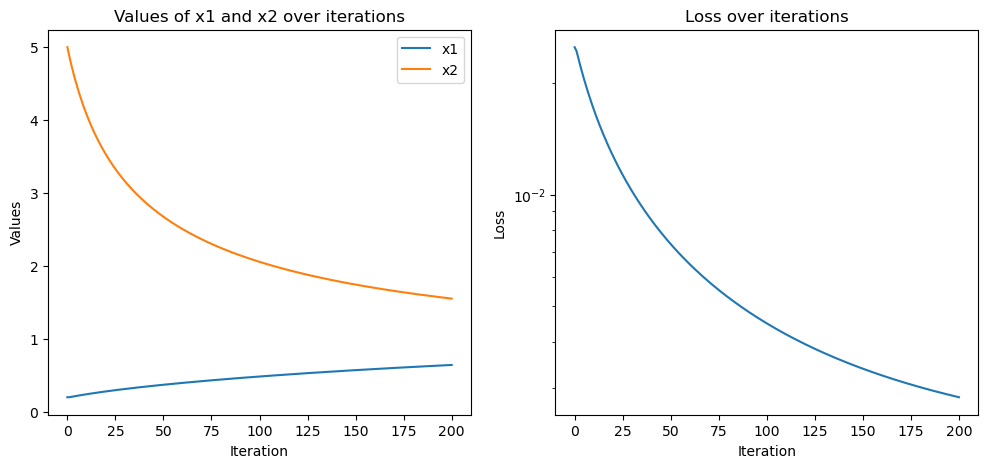

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].plot(x1store, label='x1')
axes[0].plot(x2store, label='x2')
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('Values')
axes[0].set_title('Values of x1 and x2 over iterations')
axes[0].legend()
axes[1].semilogy(loss, label='Loss')
axes[1].set_xlabel('Iteration')
axes[1].set_ylabel('Loss')
axes[1].set_title('Loss over iterations')   
plt.show()

Interestingly, the toy problem {eq}`eq:toy-pb` has a simple closed form solution that can be obtained by optimally balancing the two scalar values $x_1$ and $x_2$ as defined in {ref}`sec:theorem-HRSI`, namely

$$
|x_1| = |x_2|.
$$

Then the optimal solution is simply (up to sign ambiguities) $x_1=x_2=\sqrt{y-\lambda}$.

This hints towards the idea that balancing optimally the estimates before, after, or within an optimization algorithm solving HRSI could help avoid the scaling swamp phenomenon. We only explore the balancing of initialization and/or outputs of an algorithm here for simplicity.

Balancing initial or final estimates of an algorithm is a straightforward operation using {prf:ref}`HRSI`. First, compute the column-wise geometric mean

$$ \beta_q = \left(\prod_{i\leq n} \left(p_i\mu_ig_i(X^\ast_i[:,q])\right)^{\frac{1}{p_i}}\right)^{\frac{1}{\sum_{i\leq n} \frac{1}{p_i}}} . $$

Then scale all columns such that their regularization is exactly $\frac{1}{p_i\mu_i}\beta_q$. For the problem of ridge-regularized nCPD, this amounts to performing for all $i$ in $\{1,2,3\}$ the balancing procedure

$$ X_i[:,q] \leftarrow \left( \prod_{j\leq 3}\|X_j[:,q]\|_2^{\frac{1}{3}} \right) \frac{X_i[:,q]}{\|X_i[:,q]\|_2}. $$ 

An example barebone implementation is shown below.

In [20]:

import matplotlib.pyplot as plt 
import tensorly as tl
from copy import deepcopy
from tensorly.solvers.penalizations import scale_factors_fro

def optimal_balancing(factors):
    rank = factors[0].shape[1]
    beta = []
    for q in range(rank):
        beta.append(tl.prod([tl.norm(factor[:,q]) ** (1 / 3) for factor in factors]))
    balanced_factors = []
    for i in range(len(factors)):
        balanced_factor = factors[i].copy()
        for q in range(rank):
            balanced_factor[:, q] =  factors[i][:, q] * beta[q] / tl.norm(factors[i][:, q])
        balanced_factors.append(balanced_factor)
    return balanced_factors



The following simulation shows the importance of balancing the initial (and sometimes the final) estimates. In {cite}`cohenEfficientAlgorithmsRegularized2025` we also show than balancing at every outer iteration in the ANLS algorithm further improves the convergence speed empirically, but this simulation only performs balancing at the first and last iteration.

Recall the ridge-regularized nCPD problem

$$
 \argmin{X_i\geq 0}  \| \mathcal{T} - \mathcal{I}_r \times_1 X_1 \times_2 X_2 \times_3 X_3 \|^2_F + \mu \left(\|X_1\|_F^2 + \|X_2\|_F^2 + \|X_3\|_F^2\right). 
$$

The reader can play around with the regularization value: high values lead to more components pruning but the effect of balancing is less prononced; low values lead to no components pruning but the importance of balancing in more visible, even after the optimization algorithm has converged.

Also note that balancing only optimizes the scales of the factors with respect to the regularization terms. To scale the factors also according to the data fitting term and therefore start the algorithm at the best scaled position, it can be useful to scale the initial guess by solving the polynomial minimization problem 

$$
    \argmin{\lambda\geq 0} \| \mathcal{T} - \lambda^3 \mathcal{I}_r \times_1 X_1 \times_2 X_2 \times_3 X_3 \|^2_F +  \mu\lambda^2 \left(\|X_1\|_F^2 + \|X_2\|_F^2 + \|X_3\|_F^2\right),
$$

which amounts to evaluating the cost at all the positive roots of the polynomial

$$
    P(\lambda) = - 6\lambda^2 \left\langle \mathcal{T}, \mathcal{I}_r \times_1 X_1 \times_2 X_2 \times_3 X_3  \right\rangle + 6\lambda^5 \|\mathcal{I}_r \times_1 X_1 \times_2 X_2 \times_3 X_3  \|_F^2 \\ + 2\mu\lambda \left(\|X_1\|_F^2 + \|X_2\|_F^2 + \|X_3\|_F^2\right).
$$

In [21]:
# Example usage of the optimal_balancing function
rank = 3
dims = [10, 11, 12]
ndims = len(dims)
noise = 0.1
itermax = 100

# Regularization hyperparameter
ridge_reg = 0.1

# Create random factors for a 3-way tensor decomposition
np.random.seed(22)  # For reproducibility   
true_factors = [tl.tensor(np.random.rand(dims[i], rank)) for i in range(ndims)]

# Creating the data (from factors or balanced factors, it leads to the same result)
CPtensor = tl.cp_tensor.CPTensor(([10**(-i) for i in range(ndims)], true_factors)) 
data = CPtensor.to_tensor() + noise * tl.tensor(np.random.randn(*dims))  # Adding some noise

# Initialization
rank_e = rank + 3  # overestimating rank for initialization
init = [10**(-i) * tl.tensor(np.random.rand(dims[i], rank_e)) for i in range(ndims)]
CPinit = tl.cp_tensor.CPTensor((None, init)) 

# Optimal scaling of the initialization
t_init_unscaled = CPinit.to_tensor()
CPinit_scaled, scale = scale_factors_fro(CPinit, data, [ridge_reg]*ndims, [0]*ndims, nonnegative=True)
init_scaled = CPinit_scaled.factors

# Balancing the unscaled initialization factors
balanced_init = optimal_balancing(init)
CPinit_balanced = tl.cp_tensor.CPTensor((None, balanced_init)) 

# Balancing the scaled initialization factors
balanced_scaled_init = optimal_balancing(init_scaled)
CPinit_scaled_balanced = tl.cp_tensor.CPTensor((None, balanced_scaled_init)) 


In [22]:
# Check that factor norms are balanced after balancing
print("Optimal scaling factors:", scale)
print("Initial factors:")
for i, factor in enumerate(CPinit.factors):
    print(f"Factor {i}: shape {factor.shape}, norm {tl.norm(factor)}")
# same for scaled factors
print("\nScaled factors:")
for i, factor in enumerate(CPinit_scaled.factors):
    print(f"Factor {i}: shape {factor.shape}, norm {tl.norm(factor)}")
# same for balanced factors
print("\nBalanced factors:")
for i, factor in enumerate(CPinit_balanced.factors):
    print(f"Factor {i}: shape {factor.shape}, norm {tl.norm(factor)}")
# same for balanced scaled factors
print("\nBalanced scaled factors:")
for i, factor in enumerate(CPinit_scaled_balanced.factors):
    print(f"Factor {i}: shape {factor.shape}, norm {tl.norm(factor)}")

Optimal scaling factors: 5.290233987029234
Initial factors:
Factor 0: shape (10, 6), norm 4.299994791774854
Factor 1: shape (11, 6), norm 0.4074799825930501
Factor 2: shape (12, 6), norm 0.04968474562511675

Scaled factors:
Factor 0: shape (10, 6), norm 22.74797859149603
Factor 1: shape (11, 6), norm 2.1556644529478346
Factor 2: shape (12, 6), norm 0.2628439299428947

Balanced factors:
Factor 0: shape (10, 6), norm 0.43822144179578987
Factor 1: shape (11, 6), norm 0.43822144179579
Factor 2: shape (12, 6), norm 0.4382214417957899

Balanced scaled factors:
Factor 0: shape (10, 6), norm 2.3182939652330408
Factor 1: shape (11, 6), norm 2.3182939652330408
Factor 2: shape (12, 6), norm 2.3182939652330408


In [23]:
# Fetching the loss values with callback
callback_loss = []
def callback(factors, unnormalized_rec_errors):
    loss = (unnormalized_rec_errors**2)/2 + sum([ridge_reg*tl.norm(factors[1][i])**2 for i in range(3)])
    callback_loss.append(loss)
    
# Running nonnegative CP decomposition with various balancing/scaling setups
from tensorly.decomposition import non_negative_parafac_hals

CPe = non_negative_parafac_hals(data, rank_e, n_iter_max=itermax, tol=0, init=deepcopy(CPinit), verbose=False, ridge_coefficients=ridge_reg, callback=callback)
loss = np.copy(callback_loss)

callback_loss = []
CPe_scaled = non_negative_parafac_hals(data, rank_e, n_iter_max=itermax, tol=0, init=deepcopy(CPinit_scaled), verbose=False, ridge_coefficients=ridge_reg, callback=callback)
loss_scaled = np.copy(callback_loss)

callback_loss = []
CPe_balanced = non_negative_parafac_hals(data, rank_e, n_iter_max=itermax, tol=0, init=deepcopy(CPinit_balanced), verbose=False, ridge_coefficients=ridge_reg, callback=callback)
loss_balanced = np.copy(callback_loss)

callback_loss = []
CPe_scaled_balanced = non_negative_parafac_hals(data, rank_e, n_iter_max=itermax, tol=0, init=deepcopy(CPinit_scaled_balanced), verbose=False, ridge_coefficients=ridge_reg, callback=callback)
loss_scaled_balanced = callback_loss

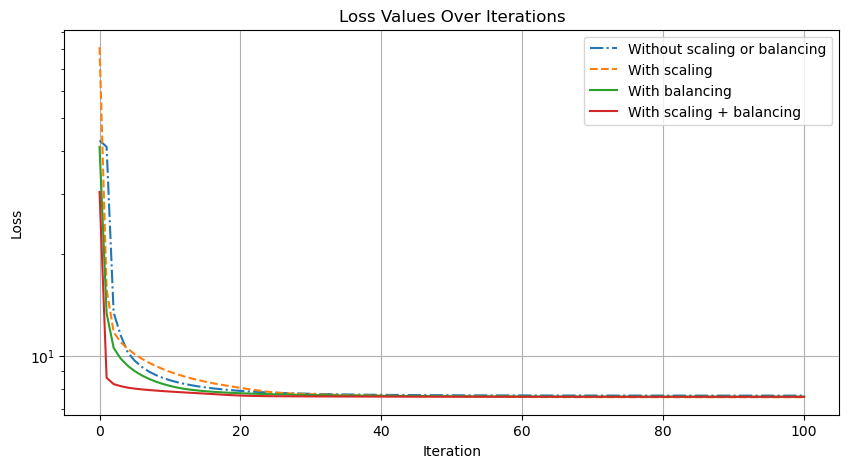

In [24]:
# Plotting the loss values
plt.figure(figsize=(10, 5))
plt.semilogy(loss, '-.', label='Loss without balancing')
plt.semilogy(loss_scaled, '--', label='Loss with scaling')
plt.semilogy(loss_balanced, label='Loss with balancing')
plt.semilogy(loss_scaled_balanced, label='Loss with balancing and scaling')
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('Loss Values Over Iterations')
plt.legend(['Without scaling or balancing', 'With scaling', 'With balancing', 'With scaling + balancing'])
plt.grid()
plt.show()

In [25]:
# Balancing the final estimated factors 
CPe_fbalance = tl.cp_tensor.CPTensor((None, optimal_balancing(CPe.factors)))
CPe_scaled_fbalance = tl.cp_tensor.CPTensor((None, optimal_balancing(CPe_scaled.factors)))
CPe_balanced_fbalance = tl.cp_tensor.CPTensor((None, optimal_balancing(CPe_balanced.factors)))
CPe_scaled_balanced_fbalance = tl.cp_tensor.CPTensor((None, optimal_balancing(CPe_scaled_balanced.factors)))

def loss(data, CPestim, ridge_reg):
    regs = sum([ridge_reg * tl.norm(factor) ** 2 for factor in CPestim.factors])
    return 0.5 * (tl.norm(data - CPestim.to_tensor()) ** 2) + regs


Final Loss values before | after rebalancing:
Without balancing or scaling:
7.640703504963442 | 7.640136375087222
With scaling:
7.558884490291016 | 7.558384623717727
With balancing:
7.58741959225447 | 7.5869139361472975
With scaling and balancing:
7.581340753614704 | 7.581238791301618


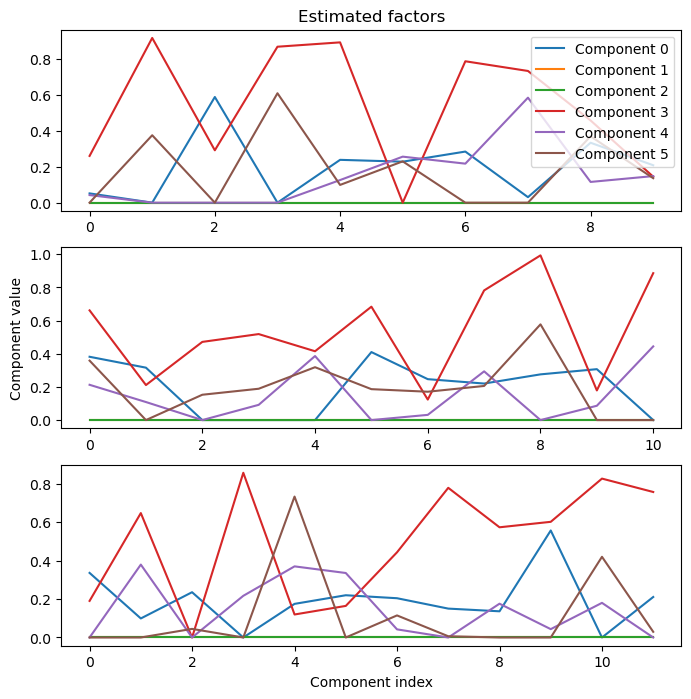

In [26]:
# Printing the final loss values before and after rebalancing
print("Final Loss values before | after rebalancing:")
print("Without balancing or scaling:")
print(f"{loss(data, CPe, ridge_reg)} | {loss(data, CPe_fbalance, ridge_reg)}")
print("With scaling:")
print(f"{loss(data, CPe_scaled, ridge_reg)} | {loss(data, CPe_scaled_fbalance, ridge_reg)}")
print("With balancing:")
print(f"{loss(data, CPe_balanced, ridge_reg)} | {loss(data, CPe_balanced_fbalance, ridge_reg)}")
print("With scaling and balancing:")
print(f"{loss(data, CPe_scaled_balanced, ridge_reg)} | {loss(data, CPe_scaled_balanced_fbalance, ridge_reg)}")

# We also analyse the number of components in the final estimates
plt.figure(figsize=(8, 8))
plt.subplot(3, 1, 1)
plt.plot(CPe_scaled_balanced.factors[0])
plt.title('Estimated factors')
plt.legend(['Component ' + str(i) for i in range(CPe_scaled_balanced.factors[0].shape[1])], loc='upper right')
plt.subplot(3, 1, 2)
plt.plot(CPe_scaled_balanced.factors[1])
plt.ylabel('Component value')
plt.subplot(3, 1, 3)
plt.plot(CPe_scaled_balanced.factors[2])
plt.xlabel('Component index')
plt.show()
